# NB14 — Forecast Trust Scoring & Decision Framework

## Objective

Previous notebooks evaluated forecast quality, operational risk and business impact.

- NB12 measured forecast risk from a business perspective
- NB13 localized the most expensive forecast failures

This notebook introduces the final decision layer.

The goal is not to train a better model.

The goal is to decide:

- when a forecast is reliable enough to trust
- when a forecast should be reviewed
- when a forecast is too risky to use without intervention

NB14 transforms forecast outputs into operational decision signals.

This notebook introduces:

- forecast trust scoring
- risk tier assignment
- decision rules
- review / fallback logic

This is not a modeling notebook.

This is a forecast governance notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path().resolve().parent))

In [2]:
# Setup
ARTIFACTS_DIR = Path("../artifacts/nb14_forecast_trust_framework")
NB11_DIR = Path("../artifacts/nb11_autogluon_extended_budget")

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

NB11_PRED_PATH = NB11_DIR / "nb11_fold_predictions.csv"

print("Setup OK")
print("Artifacts dir:", ARTIFACTS_DIR.resolve())

Setup OK
Artifacts dir: /home/donatocorbacio/projects/store-sales-project/artifacts/nb14_forecast_trust_framework


## Load Prediction Artifacts

NB14 uses the strongest operational candidate identified in previous notebooks:

- NB11 (AutoGluon extended budget)

NB11 was selected because it showed lower operational risk
in the most expensive forecast segments.

The objective is now to evaluate forecast trust,
not predictive superiority.

In [3]:
preds = pd.read_csv(NB11_PRED_PATH, parse_dates=["date"])

print("Predictions shape:", preds.shape)
display(preds.head())

Predictions shape: (49896, 7)


,fold,date,store_nbr,family,sales,prediction,onpromotion
0,2,2017-07-19,1,0,7.0,10.533682,0
1,2,2017-07-20,1,0,4.0,8.521036,0
2,2,2017-07-21,1,0,10.0,9.044243,0
3,2,2017-07-22,1,0,8.0,0.000000,0
4,2,2017-07-23,1,0,0.0,0.000000,0


## Build Evaluation Frame

To estimate forecast trust, predictions are converted into
a decision-oriented evaluation frame.

For each prediction we compute:

- raw forecast error
- absolute forecast error
- relative forecast error
- underforecast flag
- overforecast flag
- revenue proxy
- weighted error exposure

These variables are used to estimate operational trust.

In [4]:
df = preds.copy()

df["error"] = df["sales"] - df["prediction"]
df["abs_error"] = np.abs(df["error"])

df["pct_error"] = np.where(
    df["sales"] > 0,
    df["abs_error"] / df["sales"],
    np.nan
)

df["underforecast"] = (df["prediction"] < df["sales"]).astype(int)
df["overforecast"] = (df["prediction"] > df["sales"]).astype(int)

df["promo_flag"] = (df["onpromotion"] > 0).astype(int)

df["revenue_proxy"] = df["sales"]
df["weighted_abs_error"] = df["abs_error"] * df["revenue_proxy"]

print("Evaluation frame ready")
display(df.head())

Evaluation frame ready


,fold,date,store_nbr,family,sales,prediction,onpromotion,error,abs_error,pct_error,underforecast,overforecast,promo_flag,revenue_proxy,weighted_abs_error
0,2,2017-07-19,1,0,7.0,10.533682,0,-3.533682,3.533682,0.504812,0,1,0,7.0,24.735774
1,2,2017-07-20,1,0,4.0,8.521036,0,-4.521036,4.521036,1.130259,0,1,0,4.0,18.084144
2,2,2017-07-21,1,0,10.0,9.044243,0,0.955757,0.955757,0.095576,1,0,0,10.0,9.557570
3,2,2017-07-22,1,0,8.0,0.000000,0,8.000000,8.000000,1.000000,1,0,0,8.0,64.000000
4,2,2017-07-23,1,0,0.0,0.000000,0,0.000000,0.000000,NaN,0,0,0,0.0,0.000000


## Build Trust Features

Forecast trust should not depend on a single variable.

Trust is estimated using operational risk signals:

- relative error
- promotion exposure
- sales intensity
- weighted operational impact
- forecast direction (underforecast risk)

These signals are combined into a trust score.

In [5]:
df["sales_segment"] = pd.qcut(
    df["sales"].clip(lower=0),
    q=4,
    labels=["low", "mid", "high", "very_high"]
)

df["sales_risk_score"] = df["sales_segment"].map({
    "low": 0.1,
    "mid": 0.3,
    "high": 0.6,
    "very_high": 1.0
}).astype(float)

df["promo_risk_score"] = df["promo_flag"] * 1.0
df["underforecast_risk_score"] = df["underforecast"] * 1.0

weighted_q95 = df["weighted_abs_error"].quantile(0.95)
df["impact_risk_score"] = np.clip(df["weighted_abs_error"] / weighted_q95, 0, 1)

df["error_risk_score"] = np.clip(df["pct_error"].fillna(0), 0, 1)

display(df.head())

,fold,date,store_nbr,family,sales,prediction,onpromotion,error,abs_error,pct_error,...,overforecast,promo_flag,revenue_proxy,weighted_abs_error,sales_segment,sales_risk_score,promo_risk_score,underforecast_risk_score,impact_risk_score,error_risk_score
0,2,2017-07-19,1,0,7.0,10.533682,0,-3.533682,3.533682,0.504812,...,1,0,7.0,24.735774,mid,0.3,0.0,0.0,0.000042,0.504812
1,2,2017-07-20,1,0,4.0,8.521036,0,-4.521036,4.521036,1.130259,...,1,0,4.0,18.084144,low,0.1,0.0,0.0,0.000031,1.000000
2,2,2017-07-21,1,0,10.0,9.044243,0,0.955757,0.955757,0.095576,...,0,0,10.0,9.557570,mid,0.3,0.0,1.0,0.000016,0.095576
3,2,2017-07-22,1,0,8.0,0.000000,0,8.000000,8.000000,1.000000,...,0,0,8.0,64.000000,mid,0.3,0.0,1.0,0.000108,1.000000
4,2,2017-07-23,1,0,0.0,0.000000,0,0.000000,0.000000,NaN,...,0,0,0.0,0.000000,low,0.1,0.0,0.0,0.000000,0.000000


## Compute Forecast Trust Score

Forecast trust is defined as the inverse of operational risk.

A weighted risk score is computed using:

- relative forecast error
- promo risk
- underforecast risk
- sales criticality
- weighted business impact

Then transformed into a trust score:

- high trust → safe to use
- medium trust → review
- low trust → fallback / manual intervention

In [6]:
df["risk_score"] = (
    0.30 * df["error_risk_score"] +
    0.20 * df["promo_risk_score"] +
    0.20 * df["underforecast_risk_score"] +
    0.15 * df["sales_risk_score"] +
    0.15 * df["impact_risk_score"]
)

df["trust_score"] = 1 - df["risk_score"]

display(df[[
    "sales",
    "prediction",
    "abs_error",
    "pct_error",
    "risk_score",
    "trust_score"
]].head())

,sales,prediction,abs_error,pct_error,risk_score,trust_score
0,7.0,10.533682,3.533682,0.504812,0.196450,0.803550
1,4.0,8.521036,4.521036,1.130259,0.315005,0.684995
2,10.0,9.044243,0.955757,0.095576,0.273675,0.726325
3,8.0,0.000000,8.000000,1.000000,0.545016,0.454984
4,0.0,0.000000,0.000000,NaN,0.015000,0.985000


## Assign Trust Tiers

Forecasts are grouped into operational trust tiers:

- Safe → forecast can be used directly
- Review → forecast should be reviewed
- Risky → forecast should trigger fallback logic

In [7]:
def assign_trust_tier(score):
    if score >= 0.70:
        return "Safe"
    elif score >= 0.45:
        return "Review"
    return "Risky"

df["trust_tier"] = df["trust_score"].apply(assign_trust_tier)

display(df["trust_tier"].value_counts())

trust_tier
Review    25409
Safe      16823
Risky      7664
Name: count, dtype: int64

## Decision Policy

Trust tiers are converted into operational actions.

This creates a simple decision policy layer:

- Safe → use forecast directly
- Review → require human review
- Risky → fallback to safer planning logic

In [8]:
decision_map = {
    "Safe": "Use Forecast",
    "Review": "Manual Review",
    "Risky": "Fallback Policy"
}

df["decision_action"] = df["trust_tier"].map(decision_map)

display(df[["trust_tier", "decision_action"]].head())

,trust_tier,decision_action
0,Safe,Use Forecast
1,Review,Manual Review
2,Safe,Use Forecast
3,Review,Manual Review
4,Safe,Use Forecast


## Trust Distribution

Inspect how forecasts are distributed across trust tiers.

,trust_tier,pct
0,Review,50.92
1,Safe,33.72
2,Risky,15.36


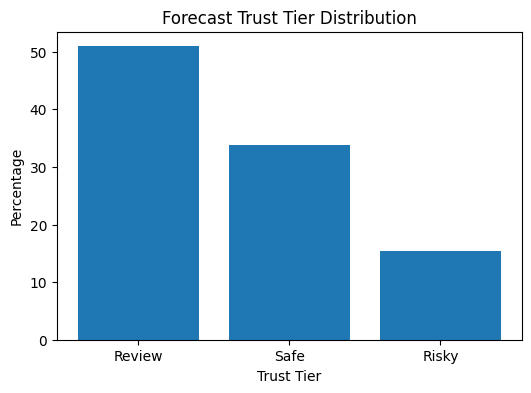

In [9]:
trust_dist = (
    df["trust_tier"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

trust_dist.columns = ["trust_tier", "pct"]
display(trust_dist)

plt.figure(figsize=(6,4))
plt.bar(trust_dist["trust_tier"], trust_dist["pct"])
plt.title("Forecast Trust Tier Distribution")
plt.ylabel("Percentage")
plt.xlabel("Trust Tier")
plt.show()

## Trust by Promo Segment

Promo periods should concentrate a larger share of low-trust forecasts.

In [10]:
promo_trust = (
    df.groupby(["promo_flag", "trust_tier"])
    .size()
    .reset_index(name="count")
)

display(promo_trust)

,promo_flag,trust_tier,count
0,0,Review,12580
1,0,Risky,26
2,0,Safe,16030
3,1,Review,12829
4,1,Risky,7638
5,1,Safe,793


## Trust by Sales Segment

High-sales observations should show lower trust and higher review pressure.

In [11]:
sales_trust = (
    df.groupby(["sales_segment", "trust_tier"])
    .size()
    .reset_index(name="count")
)

display(sales_trust)

,sales_segment,trust_tier,count
0,low,Review,4590
1,low,Risky,39
2,low,Safe,8907
3,mid,Review,6590
4,mid,Risky,288
5,mid,Safe,4544
6,high,Review,8322
7,high,Risky,1523
8,high,Safe,2619
9,very_high,Review,5907


## Action Summary

Summarize operational actions generated by the trust framework.

In [12]:
action_summary = (
    df["decision_action"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

action_summary.columns = ["decision_action", "pct"]

display(action_summary)

,decision_action,pct
0,Manual Review,50.92
1,Use Forecast,33.72
2,Fallback Policy,15.36


## Save Artifacts

Persist trust-scored forecasts for downstream operational use.

In [13]:
OUTPUT_PATH = ARTIFACTS_DIR / "nb14_forecast_trust_scored.csv"
SUMMARY_PATH = ARTIFACTS_DIR / "nb14_action_summary.csv"

df.to_csv(OUTPUT_PATH, index=False)
action_summary.to_csv(SUMMARY_PATH, index=False)

print("Saved:")
print(OUTPUT_PATH)
print(SUMMARY_PATH)

Saved:
../artifacts/nb14_forecast_trust_framework/nb14_forecast_trust_scored.csv
../artifacts/nb14_forecast_trust_framework/nb14_action_summary.csv


## Final Takeaways

NB14 adds the final operational layer to the forecasting pipeline.

Previous notebooks answered:

- how accurate the forecast is
- where the model fails
- how costly those failures are

NB14 answers the final production question:

- when should the business trust the forecast?

This notebook transforms forecasting
from a prediction problem
into a decision system.

This is the final operational layer
required before production.